In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
cd drive/MyDrive/AIML/model2

[Errno 2] No such file or directory: 'drive/MyDrive/AIML/model2'
/content/drive/MyDrive/AIML/model2


In [11]:
ls -l

total 2
-rw------- 1 root root 1374 Jul  9 03:14 house_data.csv


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import  joblib

In [15]:
df = pd.read_csv("house_data.csv")
df.head()

,SquareFeet,BHK,AreaType,Price
0,650,1,Residential,2800000
1,700,1,Residential,3000000
2,750,1,Residential,3200000
3,800,1,Residential,3500000
4,850,1,Residential,3700000


In [16]:
df.shape

(50, 4)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   SquareFeet  50 non-null     int64 
 1   BHK         50 non-null     int64 
 2   AreaType    50 non-null     object
 3   Price       50 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.7+ KB


In [18]:
df = pd.get_dummies(df, columns=['AreaType'], drop_first=True)

df.head()

,SquareFeet,BHK,Price,AreaType_Residential
0,650,1,2800000,True
1,700,1,3000000,True
2,750,1,3200000,True
3,800,1,3500000,True
4,850,1,3700000,True


In [19]:
X = df.drop('Price', axis=1)

y = df['Price']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [21]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [22]:
predictions = model.predict(X_test)

predictions

array([ 6490088.28333013, 15702177.66119514,  9741817.23669402,
       19914766.52781972,  7535761.69676924, 23425257.25000687,
       10695203.34673767, 10344154.27451896, 10787490.65013313,
        8237859.84120667])

In [23]:
print("MAE :", mean_absolute_error(y_test, predictions))

print("MSE :", mean_squared_error(y_test, predictions))

print("R2 Score :", r2_score(y_test, predictions))

MAE : 117036.57256182861
MSE : 27129939743.05541
R2 Score : 0.9990512016596819


In [24]:
result = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': predictions
})

result

,Actual Price,Predicted Price
13,6200000,6.490088e+06
39,15700000,1.570218e+07
30,9600000,9.741817e+06
45,19900000,1.991477e+07
17,7500000,7.535762e+06
48,23500000,2.342526e+07
26,11000000,1.069520e+07
25,10600000,1.034415e+07
32,10800000,1.078749e+07
19,8200000,8.237860e+06


In [25]:
new_house = pd.DataFrame({
    'SquareFeet': [1800],
    'BHK': [3],
    'AreaType_Residential': [True]
})

predicted_price = model.predict(new_house)

print("Predicted House Price = ₹", predicted_price[0])

Predicted House Price = ₹ 9642056.130081525


In [26]:
new_house = pd.DataFrame({
    'SquareFeet': [1800],
    'BHK': [3],
    'AreaType_Residential': [False]
})

predicted_price = model.predict(new_house)

print("Predicted Commercial Price = ₹", predicted_price[0])

Predicted Commercial Price = ₹ 12191686.939007988


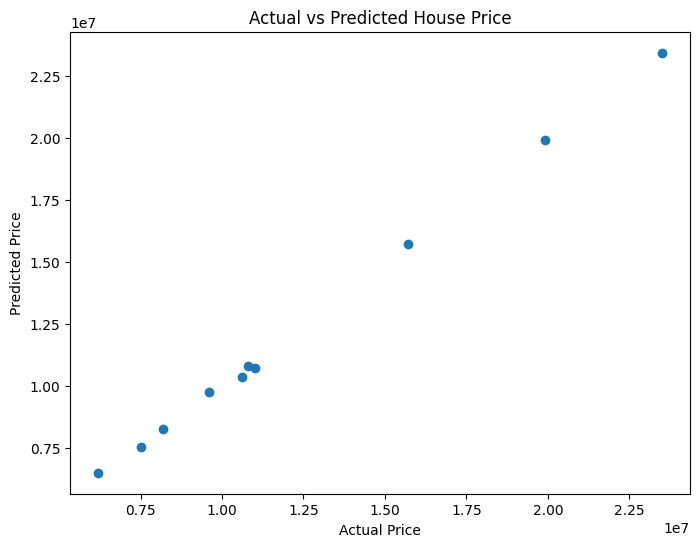

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Price")

plt.show()

In [30]:
sqft = float(input("Enter Square Feet: "))
bhk = int(input("Enter BHK: "))
area = input("Residential or Commercial: ")

if area.lower() == "residential":
    residential = True
else:
    residential = False

new_house = pd.DataFrame({
    'SquareFeet': [sqft],
    'BHK': [bhk],
    'AreaType_Residential': [residential]
})

price = model.predict(new_house)

print("Estimated Price = ₹", round(price[0], 2))

Enter Square Feet: 2000
Enter BHK: 2
Residential or Commercial: commercial
Estimated Price = ₹ 13954406.1


In [35]:
joblib.dump(model, 'house_price_model.pkl')

['house_price_model.pkl']